In [2]:
from utils.parser import benchmarking, benchmarking_batch, compute_acc
from utils.dataloader import load_data, load_data_batch
import json

if __name__ == "__main__":
    '''
    load data in batch from the data folder by fields
    '''
    # field = "general"
    # data = load_data_batch(field=field)
    
    '''
    load test example for testing
    '''
    data_path = "data/tmp.json"
    image_path = "data/tmp"
    data = load_data(data_path, image_path)

    '''
    benchmarking the model using one question
    '''
    field = "general"
    # available models:
    # llama2_7b, llama2_13b, llama3_8b_instruct, mistrial_7b, gpt35, gpt4o, gpt4
    return_data = benchmarking(data, field, model_name='gpt4o')
    results, comparisons = compute_acc(return_data)

    print(f"results: {results}")
    print(json.dumps({"comparison": comparisons}, ensure_ascii=False, indent=4))
    '''
    benchmarking the model using batch of questions
    '''
    # benchmarking_batch(data)


Testing: 
This question is from ucb_course
STATEMENT: Consider the circuit in the image. X and Y update at each rising edge of the clock. You are given the following: the adder propagation delay is 2ns; the register setup time is 2ns; the register hold time is 4ns; the register clk-to-q delay is 3ns; the clock frequency is 100MHz.
Hint: if an input updates at each rising edge of the clock, you can think of it as an output from a register with 0 clk-to-q delay.
As a reminder, a circuit must fulfill the following conditions in order to exhibit consistently correct behavior:
t_{clk-to-q}+t_{shortest-combinational-path}>=t_{hold}
t_{clk-to-q}+t_{longest-combinational-path}+t_{setup}<=t_{clk-period}

QUESTION: After the rising edge of the clock, how many nanoseconds elapse before the input to the register changes?
Hint: consider all the paths going into the register, the shortest one will induce the first input change to the register.
Extracted Answer: 5
Extracted Explanation: The shortest 

In [1]:
import os
from PIL import Image

# 获取图像文件夹路径
image_folder = "data/tmp"

# 列出文件夹中的所有文件
image_files = os.listdir(image_folder)

# 遍历每个文件并重命名和压缩
for index, image_file in enumerate(image_files):
    # 获取文件的完整路径
    old_file_path = os.path.join(image_folder, image_file)
    
    # 打开图像并压缩
    with Image.open(old_file_path) as img:
        img = img.convert("RGB")  # 确保图像是RGB格式
        img = img.resize((img.width // 2, img.height // 2))  # 将图像尺寸缩小一半
        
        # 构建新的文件名和路径
        new_file_name = f"image_{index}.png"
        new_file_path = os.path.join(image_folder, new_file_name)
        
        # 保存压缩后的图像
        img.save(new_file_path, "PNG")

print("Images have been renamed and compressed based on their index.")


Images have been renamed and compressed based on their index.


In [7]:
from openai import OpenAI

api_key = "4ik5Y3F4-TbXAzhu7Q12uIeg-U9AGYGUQqMlsMZdjK4"
base_url = "http://127.0.0.1:10000/v1/"

def query_gpt35(prompt, images=None, image_captions=None):
    openai_api_key = api_key
    openai_api_base = base_url
    client = OpenAI(api_key=openai_api_key, base_url=openai_api_base)
    messages = [
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": prompt}
    ]
    llm_response = client.chat.completions.create(
        messages=messages,
        model="GPT-3.5-Turbo",
        max_tokens=1024,
        temperature=0.7,
        stream=False  
    )
    llm_outputs = llm_response.choices[0].message.content
    return llm_outputs

prompt = "hello"

response = query_gpt35(prompt)
print(response)

KeyboardInterrupt: 

### Count the types of questions

In [4]:
import json

data_path = "/home/xiangyu/project/multimodalEDABenchmarking/data/backend.json"
# data_path = "/home/xiangyu/project/multimodalEDABenchmarking/data/rtl.json"


with open(data_path, 'r') as file:
    data = json.load(file)

    types = []
    for key in data.keys():
        instance_types = data[key]['question_type']
        for i in range(len(instance_types)):
            if instance_types[i] not in types:
                types.append(instance_types[i])


    print(types)


['open', 'blank', 'multi', 'single']


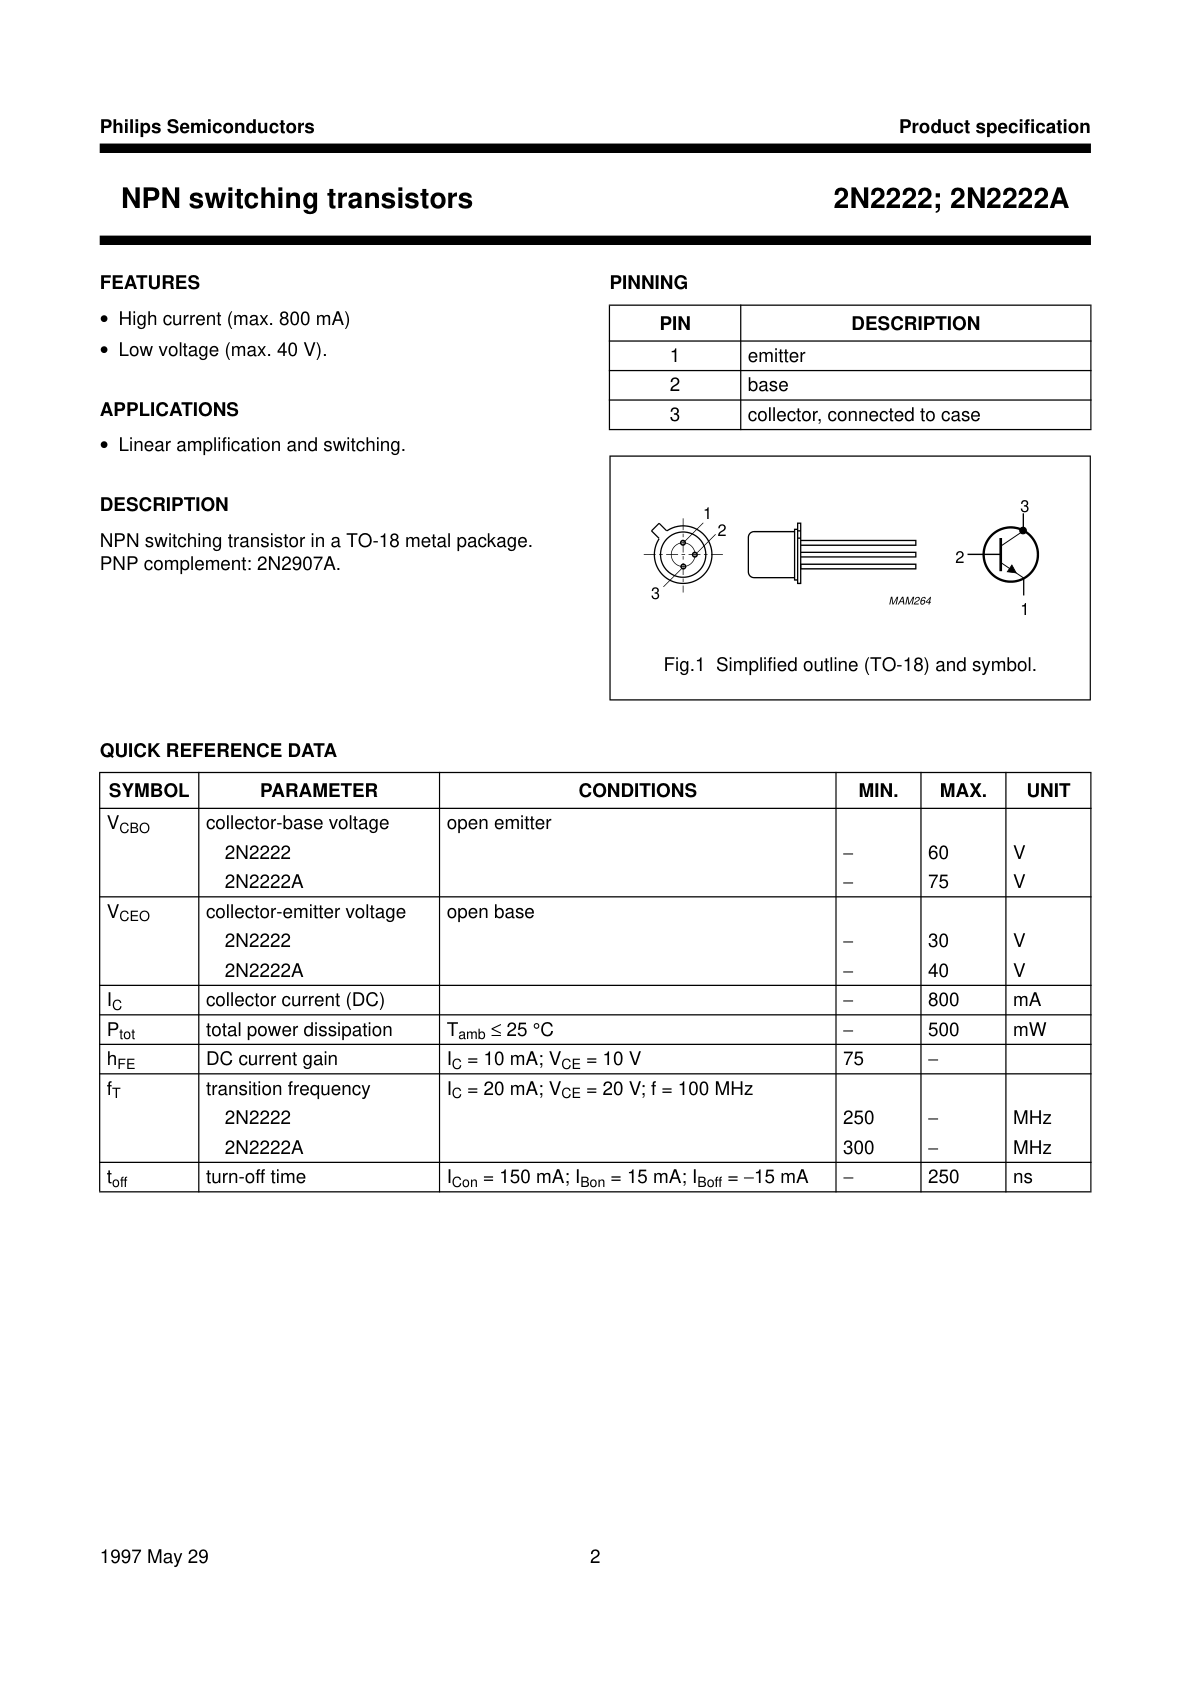

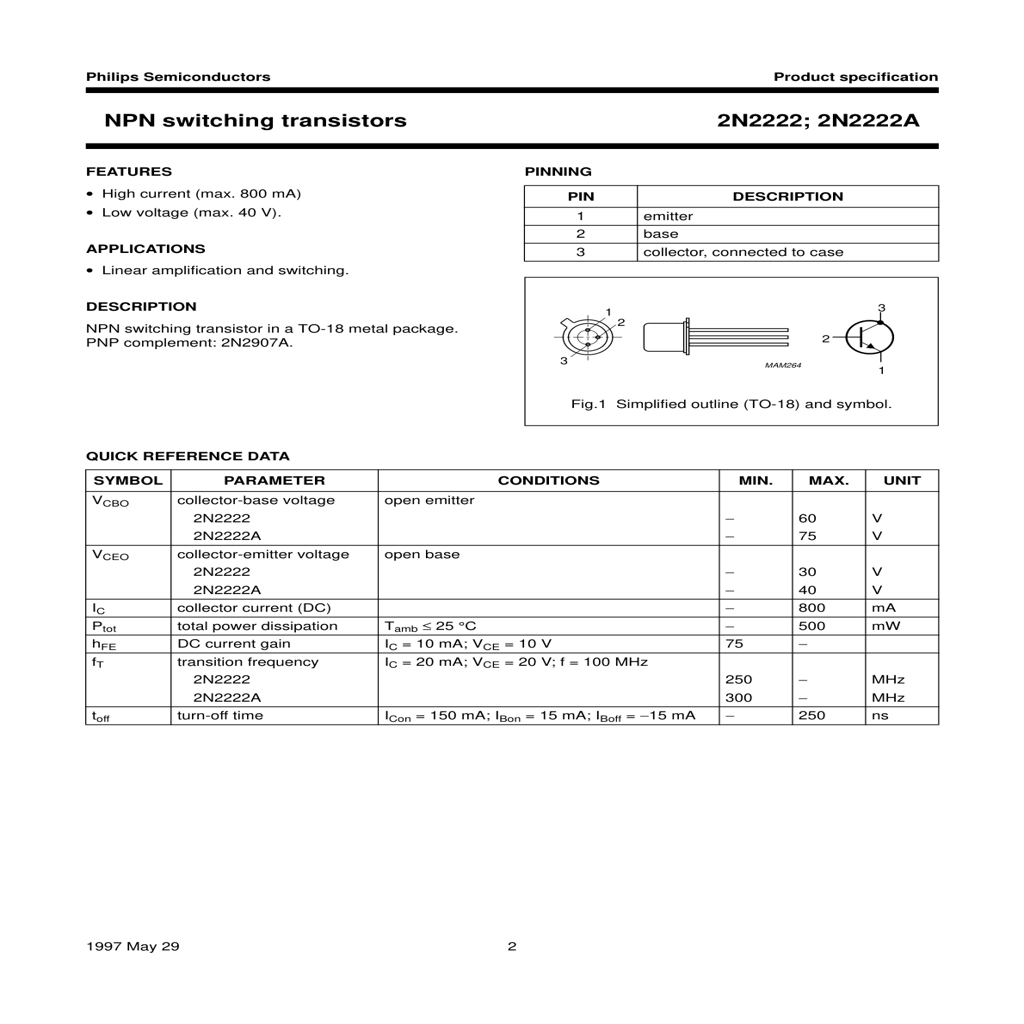

1024 1024


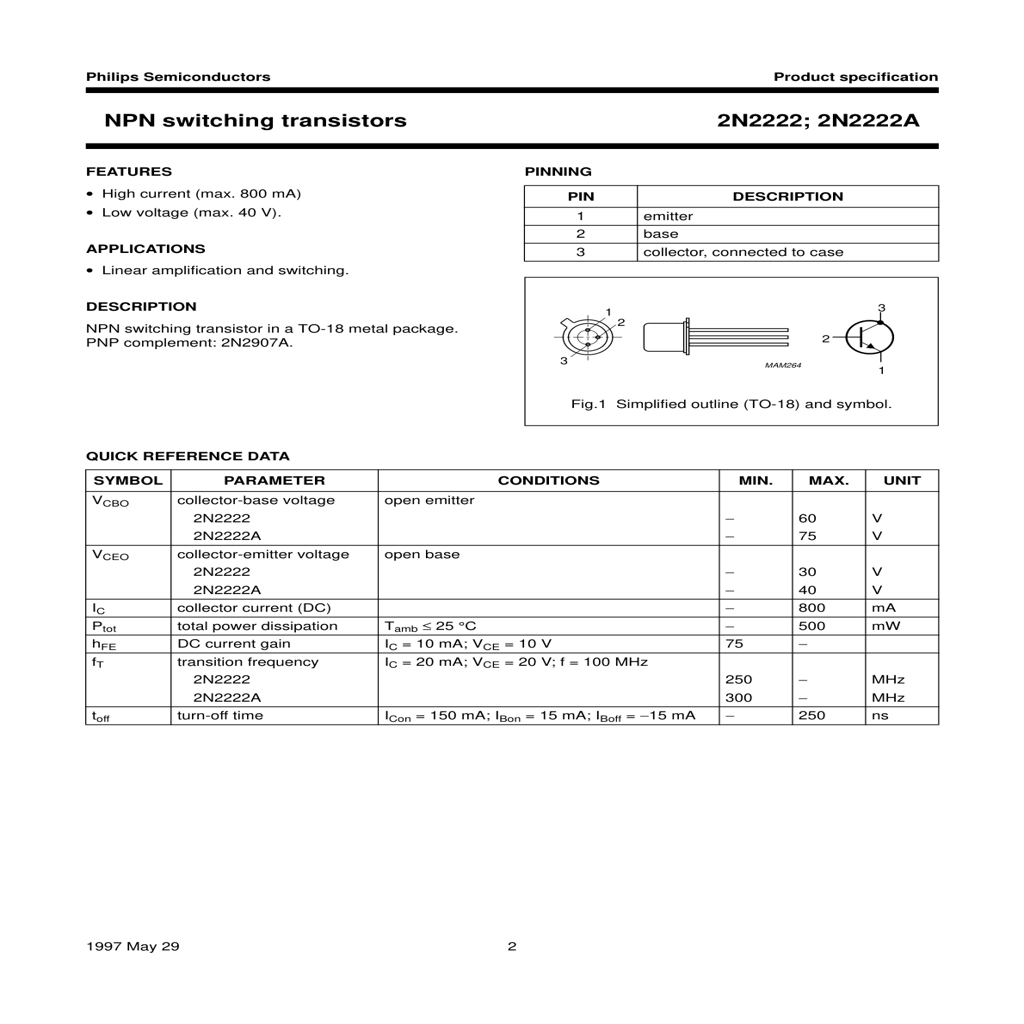

In [10]:
from PIL import Image
from cv2 import resize

image_path = "/home/xiangyu/project/multimodalEDABenchmarking/data/spec/2N2222_page2.png"
image = Image.open(image_path)
image.show()

image = image.resize((1024, 1024))
image.show()

# 获取图像的宽度和高度
width, height = image.size
print(width, height)
# 计算新的尺寸，保持长边为512
if width > height:
    new_width = 1024
    new_height = int((1024 / width) * height)
else:
    new_height = 1024
    new_width = int((1024 / height) * width)

# 调整图像大小
resized_image = image.resize((new_width, new_height))

resized_image.show()